# Phase 2 Part 2: Exploratory Data Analysis & Quality Summary

> **CRISP-DM Phase**: 2 of 6 — Data Understanding  
> **Project**: Opioid Pipeline Analysis  
> **Author**: Krunal  
> **Date**: March 2026  
> **Analysis Year**: 2020  

## Purpose

This notebook completes CRISP-DM Phase 2 with:
1. **7 EDA visualizations** exploring prescribing patterns, death trends, and socioeconomic distributions
2. **Final data quality summary** consolidating all findings from Part 1
3. **10 documented decisions** that will guide Phase 3 (Data Preparation)

### Key Adaptations from Part 1 Discoveries
- Using **single year 2020** (not multi-year) — Viz 1 adapted accordingly
- CDC indicator switched to **"Natural & semi-synthetic opioids, incl. methadone (T40.2, T40.3)"** (42 states vs 20)
- Both CDC and AHRQ data have **duplicate rows** — handled with DISTINCT in queries
- 5 false-positive drugs excluded from CMS queries
- CDC joins use **`state_name`** column, not `state`

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style settings for all charts
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paths
PROJECT_ROOT = Path('.').resolve().parent
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# Database connection
engine = create_engine('postgresql://yashcomputers@localhost:5432/opioid_analysis')
with engine.connect() as conn:
    result = conn.execute(text('SELECT current_database()'))
    print(f'Connected to: {result.fetchone()[0]}')

# False-positive drugs to exclude from CMS queries
FALSE_POSITIVES = (
    "'Tiotropium Bromide', 'Ipratropium Bromide', "
    "'Ipratropium/Albuterol Sulfate', 'Tiotropium Br/Olodaterol Hcl', "
    "'Apomorphine Hcl'"
)

print(f'Figures will be saved to: {FIGURES_DIR}')
print('Setup complete.')

Connected to: opioid_analysis
Figures will be saved to: /Users/krunal/opioid-pipeline-analysis/figures
Setup complete.


---
## Visualization 1: Top Opioid Drugs by Prescription Volume

Since we have a single year (2020) instead of multiple years, we replace the planned national
trend line with a **drug-level breakdown** showing which opioids dominate Medicare prescribing.

**Business relevance**: Tells the stakeholder which specific drugs drive the highest prescribing
volume — useful for targeted prescriber education campaigns.

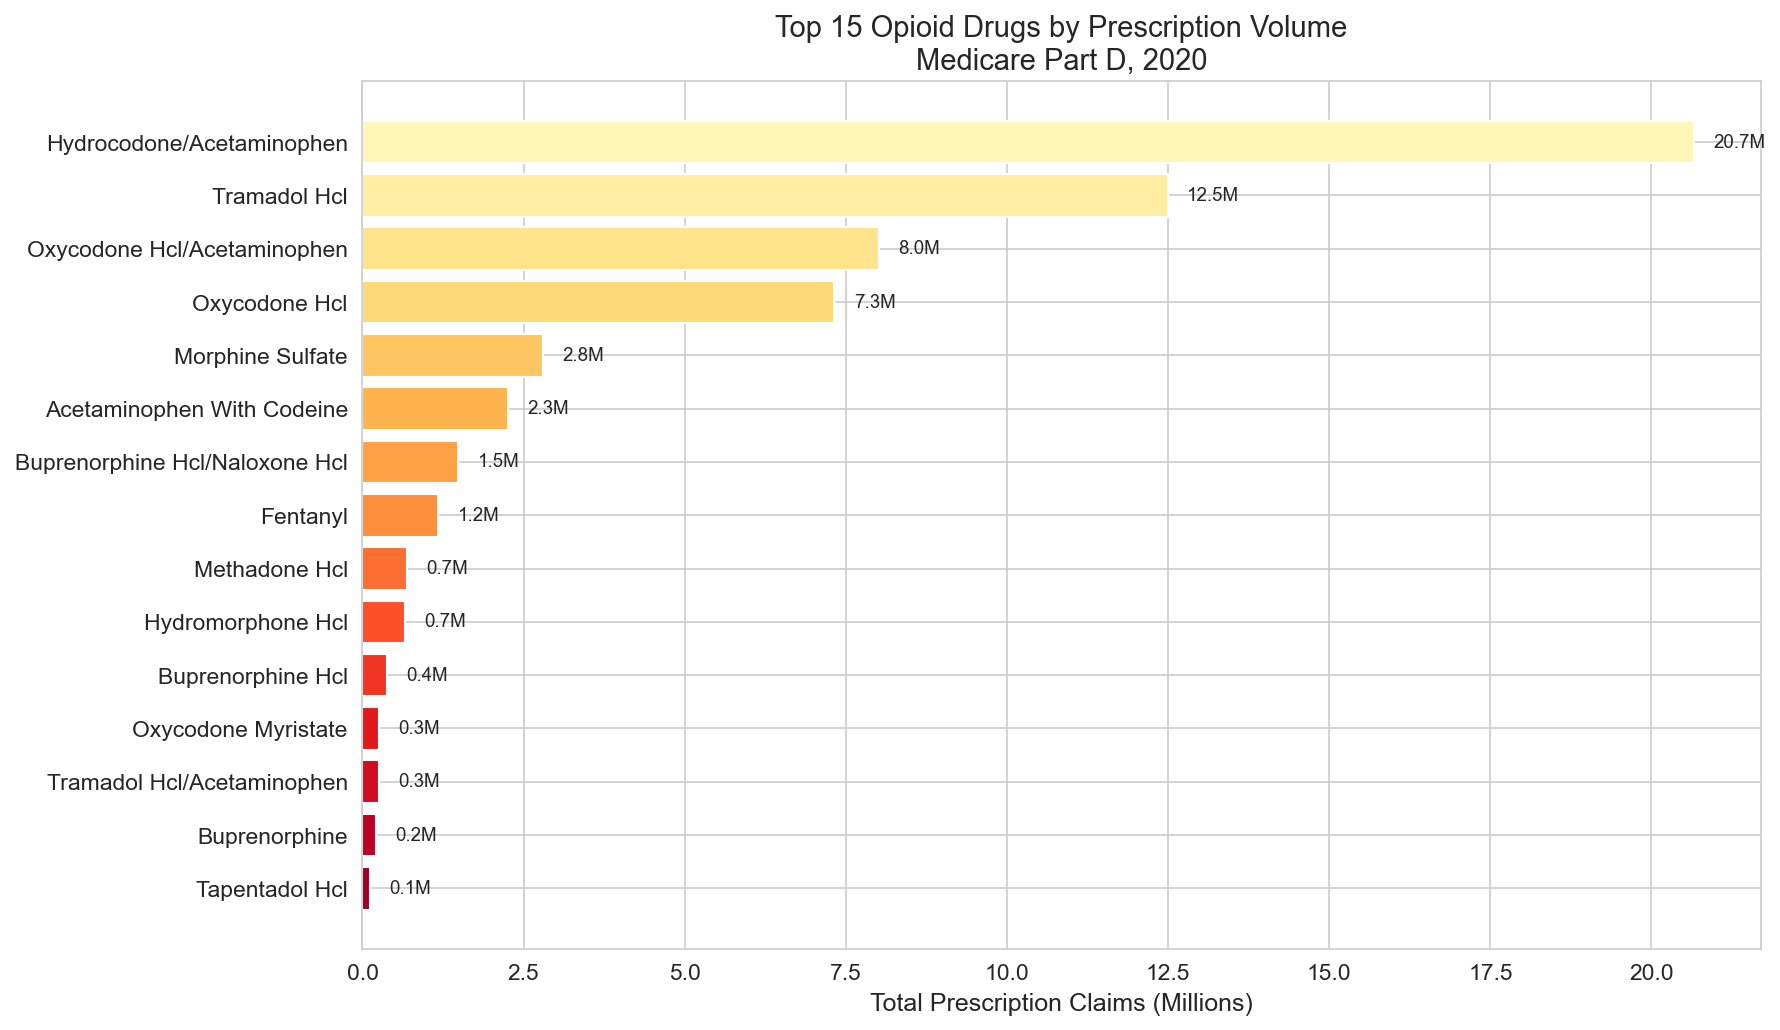

Saved to /Users/krunal/opioid-pipeline-analysis/figures/01_top_opioid_drugs.png


In [2]:
# ============================================================
# Viz 1: Top 15 Opioid Drugs by Total Claims (2020)
# ============================================================

# Query: aggregate claims by drug, exclude false positives
drug_claims = pd.read_sql(f"""
    SELECT gnrc_name,
           SUM(tot_clms) AS total_claims,
           COUNT(DISTINCT prscrbr_npi) AS prescribers
    FROM stg_cms_partd
    WHERE gnrc_name NOT IN ({FALSE_POSITIVES})
    GROUP BY gnrc_name
    ORDER BY total_claims DESC
    LIMIT 15;
""", engine)

# Plot: horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    drug_claims['gnrc_name'][::-1],          # Reverse for highest at top
    drug_claims['total_claims'][::-1] / 1e6,  # Convert to millions
    color=sns.color_palette('YlOrRd_r', 15)
)
ax.set_xlabel('Total Prescription Claims (Millions)')
ax.set_title('Top 15 Opioid Drugs by Prescription Volume\nMedicare Part D, 2020')

# Add value labels on bars
for bar, val in zip(bars, drug_claims['total_claims'][::-1] / 1e6):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_top_opioid_drugs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIGURES_DIR / "01_top_opioid_drugs.png"}')

### ✏️ Viz 1 Observations
_(Fill in after running: Which drug dominates? What % of total does the top 3 represent?)_

---
## Visualization 2: State-Level Opioid Prescribing Rates

**Business relevance**: Directly answers "which states have the highest opioid prescribing intensity?"  
Expected: Southeast states (AL, TN, WV, KY, MS) rank highest.

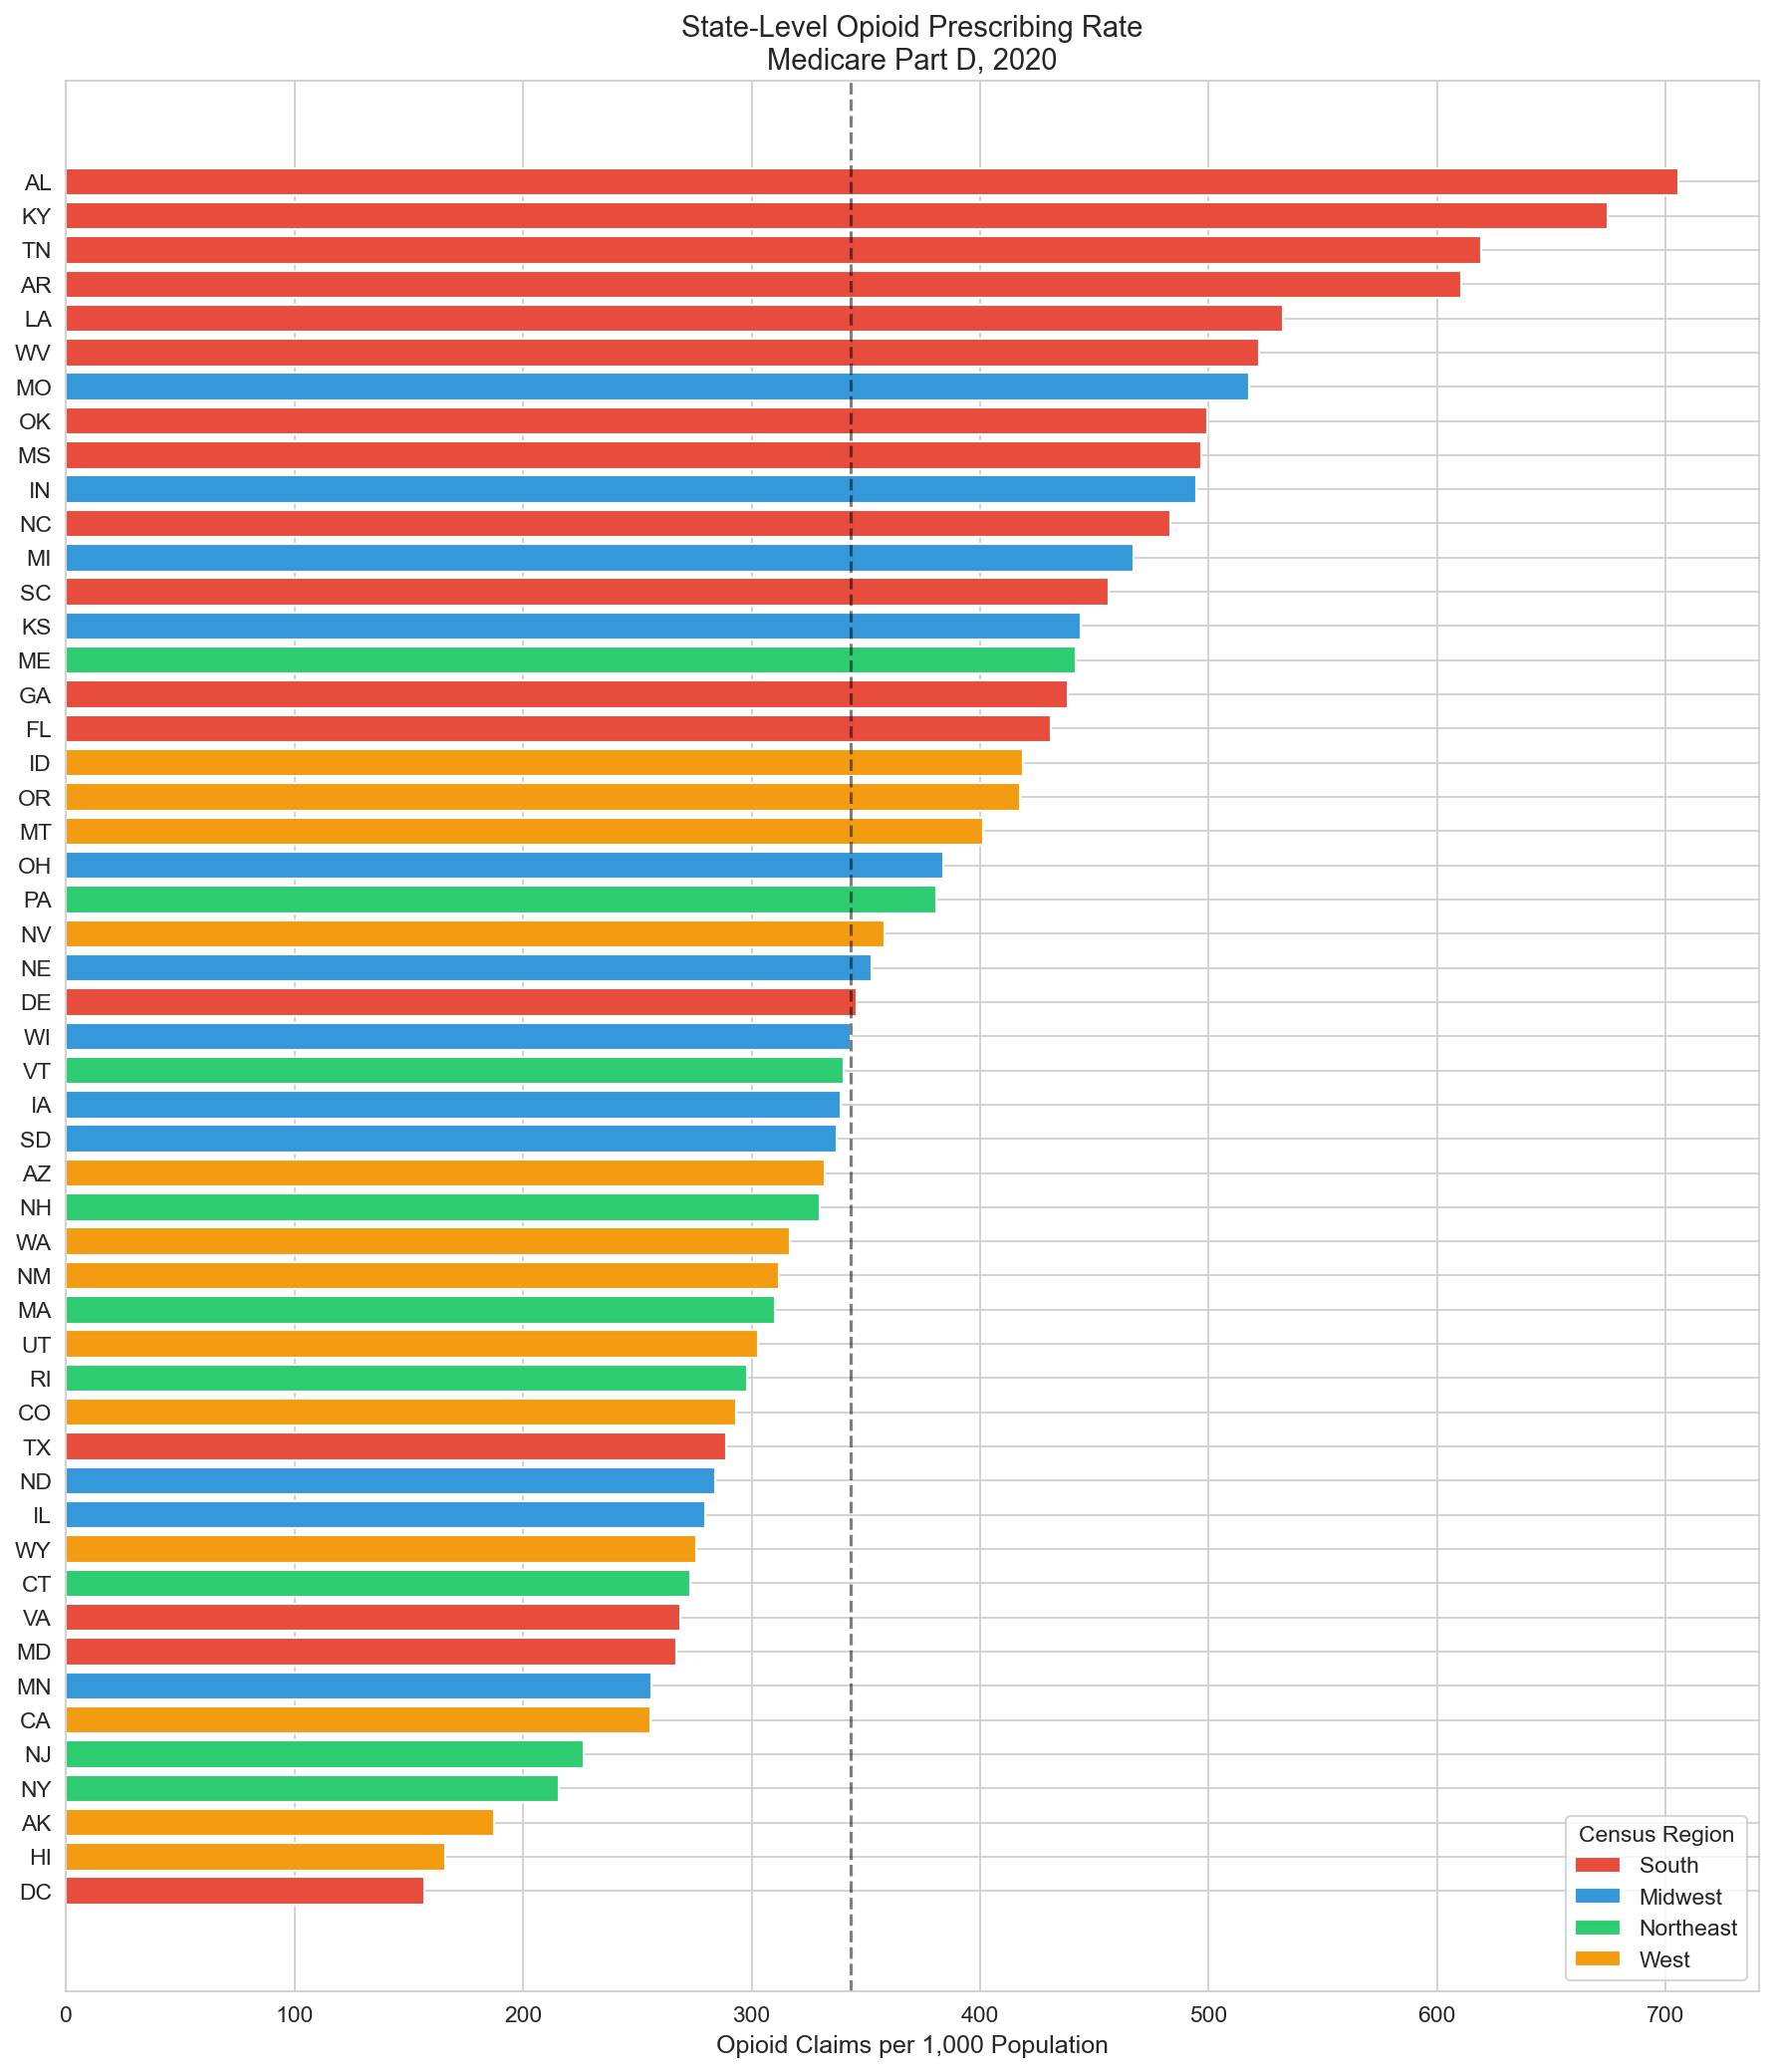

In [14]:
# ============================================================
# Viz 2: State-Level Opioid Prescribing Rate (Claims per 1K beneficiaries)
# ============================================================

# We need total opioid claims AND total beneficiaries by state.
# Since tot_benes is 54% suppressed, we use tot_clms as the metric
# and normalize by state population from AHRQ.

state_prescribing = pd.read_sql(f"""
    SELECT d.state_abbrev,
           d.state_name,
           d.census_region,
           SUM(c.tot_clms) AS opioid_claims,
           -- Get state population from AHRQ (deduplicated)
           pop.state_pop
    FROM stg_cms_partd c
    JOIN dim_state d ON TRIM(c.prscrbr_state_abrvtn) = d.state_abbrev
    JOIN (
        SELECT statefips, SUM(total_population) / 2 AS state_pop  -- Divide by 2 for dedup
        FROM stg_ahrq_sdoh
        WHERE total_population IS NOT NULL
        GROUP BY statefips
    ) pop ON d.state_fips = pop.statefips
    WHERE c.gnrc_name NOT IN ({FALSE_POSITIVES})
    GROUP BY d.state_abbrev, d.state_name, d.census_region, pop.state_pop
    ORDER BY opioid_claims DESC;
""", engine)

# Calculate prescribing rate per 1,000 population
state_prescribing['rx_rate_per_1k'] = (
    state_prescribing['opioid_claims'] / state_prescribing['state_pop'] * 1000
)

# Sort by rate for plotting
state_prescribing_sorted = state_prescribing.sort_values('rx_rate_per_1k', ascending=True)

# Plot: horizontal bar chart colored by census region
region_colors = {'South': '#e74c3c', 'Midwest': '#3498db',
                 'Northeast': '#2ecc71', 'West': '#f39c12'}

fig, ax = plt.subplots(figsize=(12, 14))
colors = [region_colors.get(r, '#95a5a6') for r in state_prescribing_sorted['census_region']]
ax.barh(state_prescribing_sorted['state_abbrev'],
        state_prescribing_sorted['rx_rate_per_1k'],
        color=colors)

# Add region legend
# Add region legend with explicit color patches
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=color, label=region) for region, color in region_colors.items()]
ax.legend(handles=legend_patches, title='Census Region', loc='lower right')

ax.set_xlabel('Opioid Claims per 1,000 Population')
ax.set_title('State-Level Opioid Prescribing Rate\nMedicare Part D, 2020')
ax.axvline(x=state_prescribing['rx_rate_per_1k'].median(), color='black',
           linestyle='--', alpha=0.5, label='Median')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_state_prescribing_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### ✏️ Viz 2 Observations
_(Fill in: Which states rank highest/lowest? Does the South dominate as expected? Any surprises?)_

---
## Visualization 3: Top Specialties by Opioid Prescribing

**Business relevance**: Identifies which medical specialties to target with prescriber education campaigns.

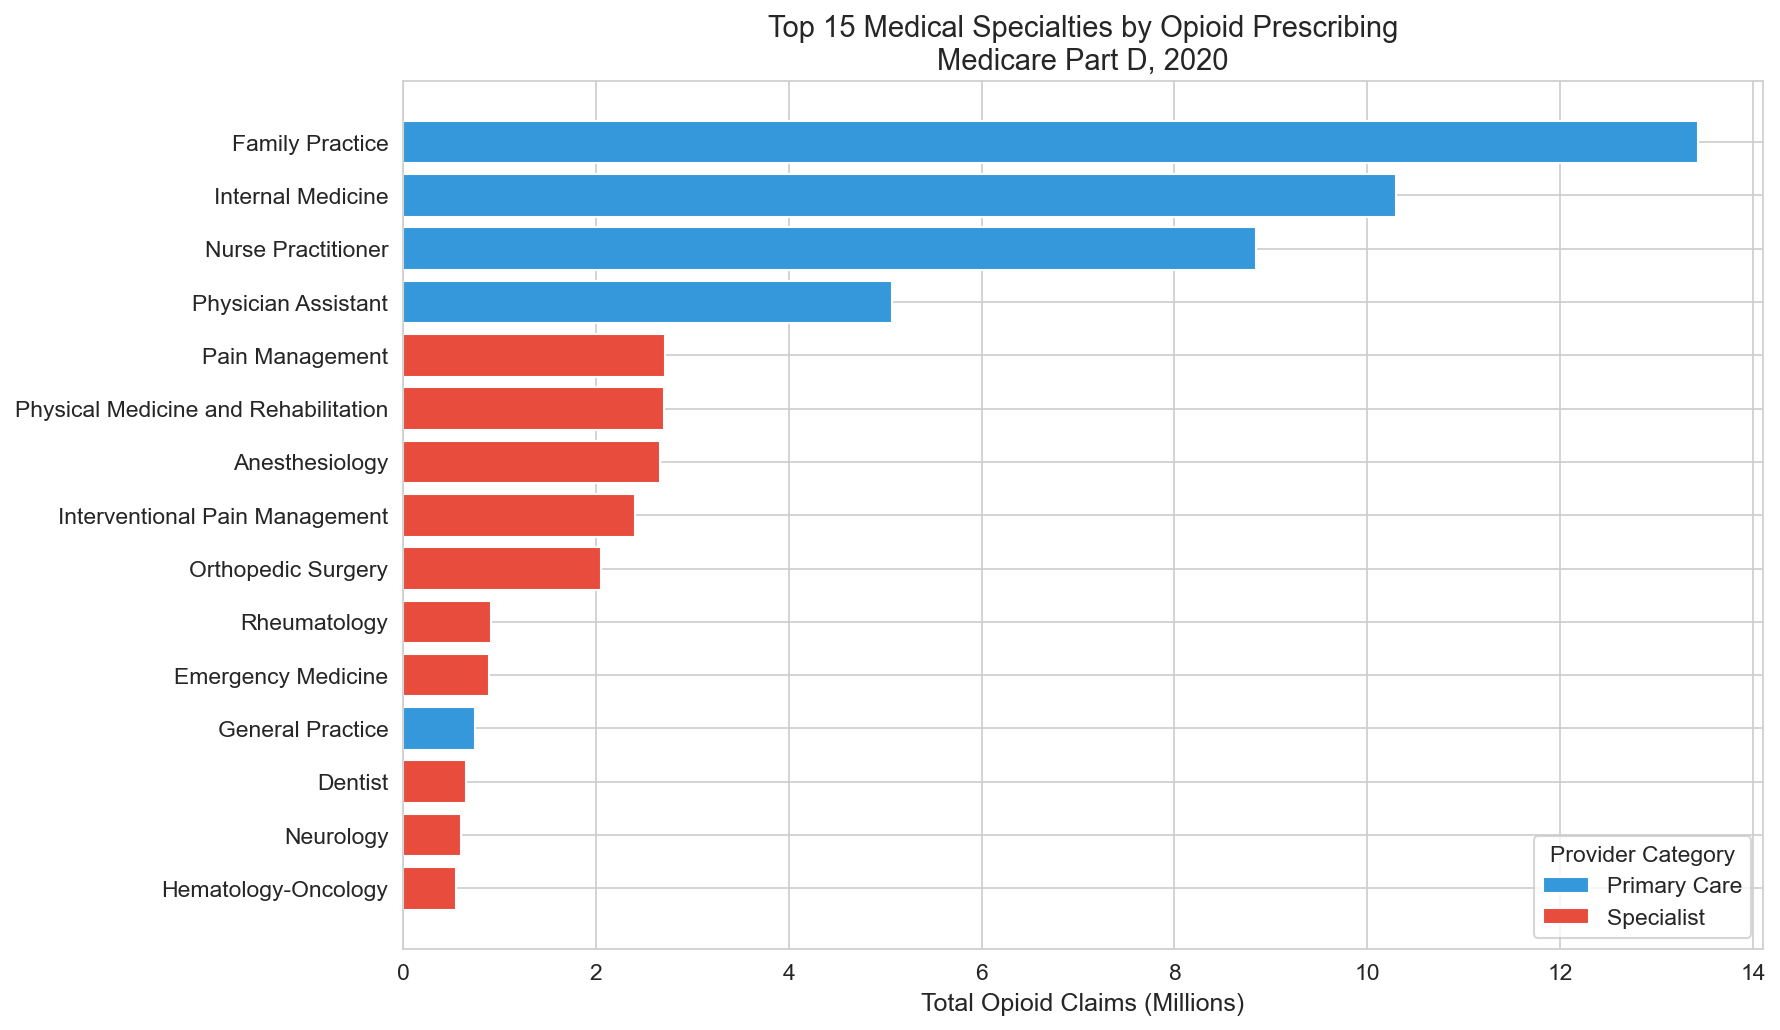

In [15]:
# ============================================================
# Viz 3: Top 15 Specialties by Opioid Claims
# ============================================================

specialty_claims = pd.read_sql(f"""
    SELECT prscrbr_type AS specialty,
           COUNT(DISTINCT prscrbr_npi) AS prescribers,
           SUM(tot_clms) AS total_claims
    FROM stg_cms_partd
    WHERE gnrc_name NOT IN ({FALSE_POSITIVES})
    GROUP BY prscrbr_type
    ORDER BY total_claims DESC
    LIMIT 15;
""", engine)

# Classify as primary care vs specialist
primary_care = ['Family Practice', 'Family Medicine', 'Internal Medicine',
                'Nurse Practitioner', 'Physician Assistant', 'General Practice']
specialty_claims['category'] = specialty_claims['specialty'].apply(
    lambda x: 'Primary Care' if x in primary_care else 'Specialist'
)

fig, ax = plt.subplots(figsize=(12, 7))
cat_colors = {'Primary Care': '#3498db', 'Specialist': '#e74c3c'}
colors = [cat_colors[c] for c in specialty_claims['category'][::-1]]

ax.barh(specialty_claims['specialty'][::-1],
        specialty_claims['total_claims'][::-1] / 1e6,
        color=colors)

from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=color, label=cat) for cat, color in cat_colors.items()]
ax.legend(handles=legend_patches, title='Provider Category', loc='lower right')

ax.set_xlabel('Total Opioid Claims (Millions)')
ax.set_title('Top 15 Medical Specialties by Opioid Prescribing\nMedicare Part D, 2020')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_top_opioid_specialties.png', dpi=150, bbox_inches='tight')
plt.show()

### ✏️ Viz 3 Observations
_(Fill in: What % of claims come from primary care? Is Pain Management surprisingly high or low relative to its prescriber count?)_

---
## Visualization 4: Overdose Death Trends by Drug Type (2015–2023)

Even though our analysis focuses on 2020, this multi-year view from CDC data is **critical**
for understanding the illicit fentanyl confound — the biggest limitation of our analysis.

**Business relevance**: Shows the stakeholder why prescription opioid deaths alone don't tell the
full story — illicit fentanyl has become the dominant driver of overdose deaths since ~2016.

Rows returned: 45


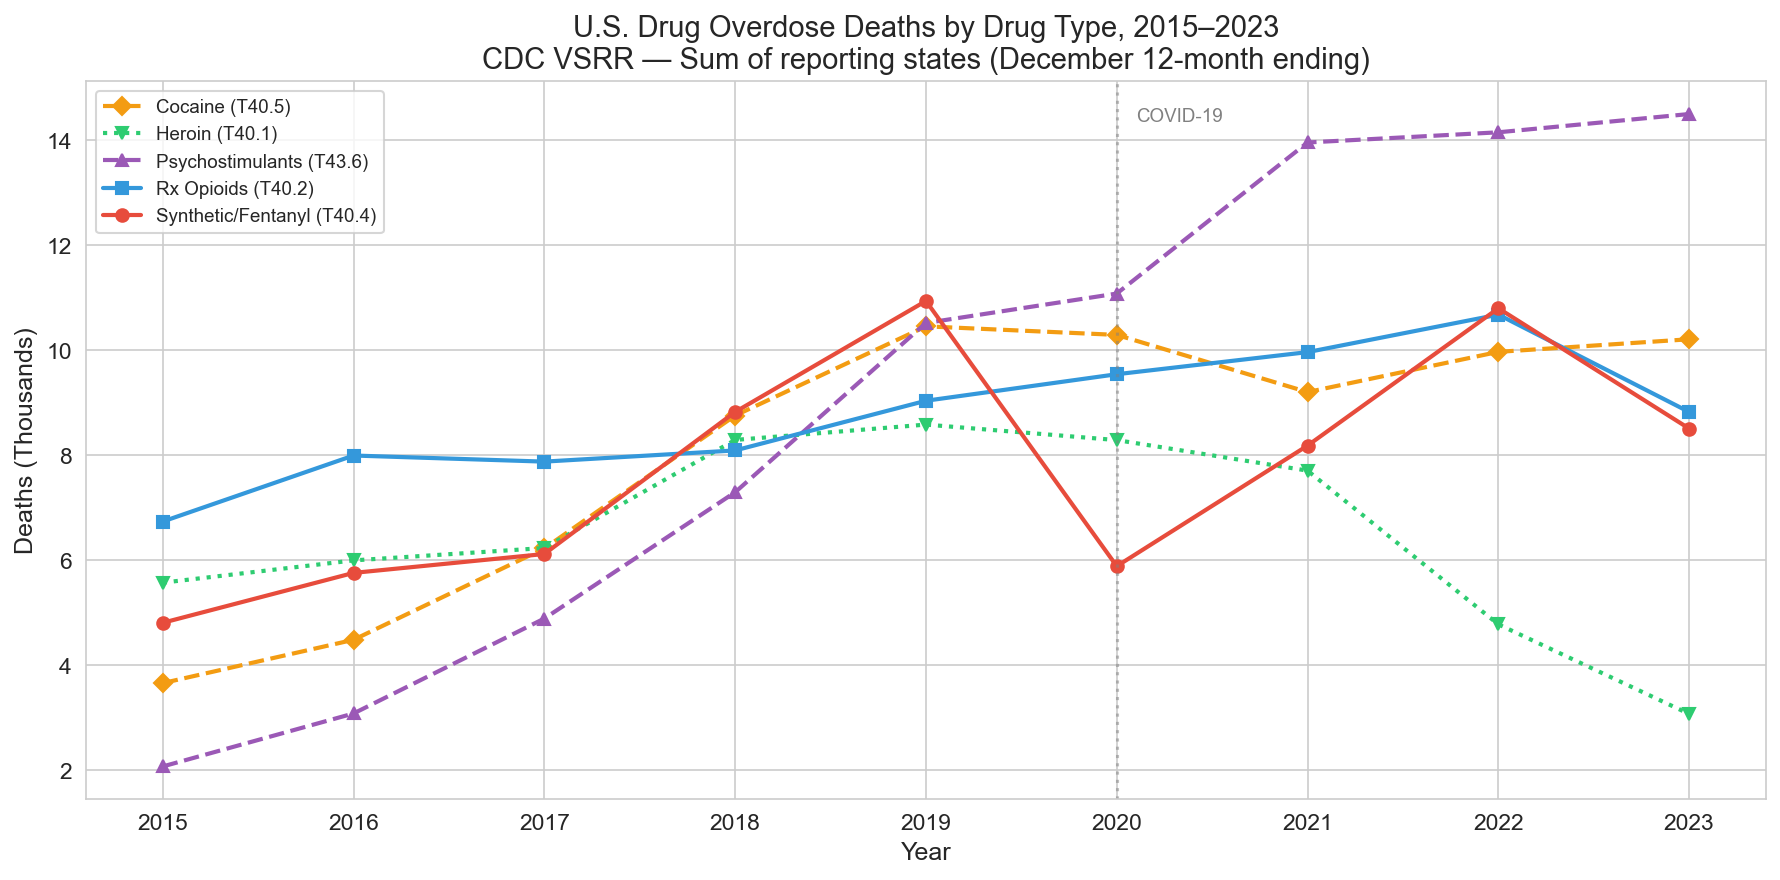

In [13]:
# ============================================================
# Viz 4: Overdose Death Trends by Drug Type (FIXED)
# ============================================================
# National totals don't exist for drug-specific indicators in CDC data.
# Solution: Sum state-level data for each indicator × year.

drug_trends = pd.read_sql("""
    SELECT year, indicator, SUM(data_value) AS deaths
    FROM (
        SELECT DISTINCT state_name, year, month, indicator, data_value
        FROM stg_cdc_overdose
        WHERE month = 'December'
          AND year BETWEEN 2015 AND 2023
          AND state_name NOT IN ('United States', 'New York City')
          AND data_value IS NOT NULL
          AND indicator IN (
              'Natural & semi-synthetic opioids (T40.2)',
              'Heroin (T40.1)',
              'Synthetic opioids, excl. methadone (T40.4)',
              'Cocaine (T40.5)',
              'Psychostimulants with abuse potential (T43.6)'
          )
    ) deduped
    GROUP BY year, indicator
    ORDER BY year, indicator;
""", engine)

print(f'Rows returned: {len(drug_trends)}')

# Shorten indicator names for legend
label_map = {
    'Natural & semi-synthetic opioids (T40.2)': 'Rx Opioids (T40.2)',
    'Heroin (T40.1)': 'Heroin (T40.1)',
    'Synthetic opioids, excl. methadone (T40.4)': 'Synthetic/Fentanyl (T40.4)',
    'Cocaine (T40.5)': 'Cocaine (T40.5)',
    'Psychostimulants with abuse potential (T43.6)': 'Psychostimulants (T43.6)',
}
drug_trends['label'] = drug_trends['indicator'].map(label_map)

fig, ax = plt.subplots(figsize=(12, 6))
line_styles = {
    'Synthetic/Fentanyl (T40.4)': ('-', 'o', '#e74c3c'),
    'Rx Opioids (T40.2)': ('-', 's', '#3498db'),
    'Psychostimulants (T43.6)': ('--', '^', '#9b59b6'),
    'Cocaine (T40.5)': ('--', 'D', '#f39c12'),
    'Heroin (T40.1)': (':', 'v', '#2ecc71'),
}

for label, group in drug_trends.groupby('label'):
    ls, marker, color = line_styles.get(label, ('-', 'o', 'gray'))
    ax.plot(group['year'], group['deaths'] / 1000, linestyle=ls, marker=marker,
            color=color, label=label, linewidth=2, markersize=6)

ax.axvline(x=2020, color='gray', linestyle=':', alpha=0.5)
ax.text(2020.1, ax.get_ylim()[1] * 0.95, 'COVID-19', fontsize=9, color='gray')

ax.set_xlabel('Year')
ax.set_ylabel('Deaths (Thousands)')
ax.set_title('U.S. Drug Overdose Deaths by Drug Type, 2015–2023\n'
             'CDC VSRR — Sum of reporting states (December 12-month ending)')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_overdose_trends_by_drug.png', dpi=150, bbox_inches='tight')
plt.show()

### ✏️ Viz 4 Observations
_(Fill in: Did synthetic/fentanyl deaths surge as expected? Did Rx opioid deaths plateau? What happened in 2020 vs 2019? This chart is critical for the limitations discussion.)_

---
## Visualization 5: SDOH Distributions Across Counties

**Business relevance**: Understanding the distribution of socioeconomic risk factors helps the
stakeholder know which community characteristics to watch for when targeting interventions.

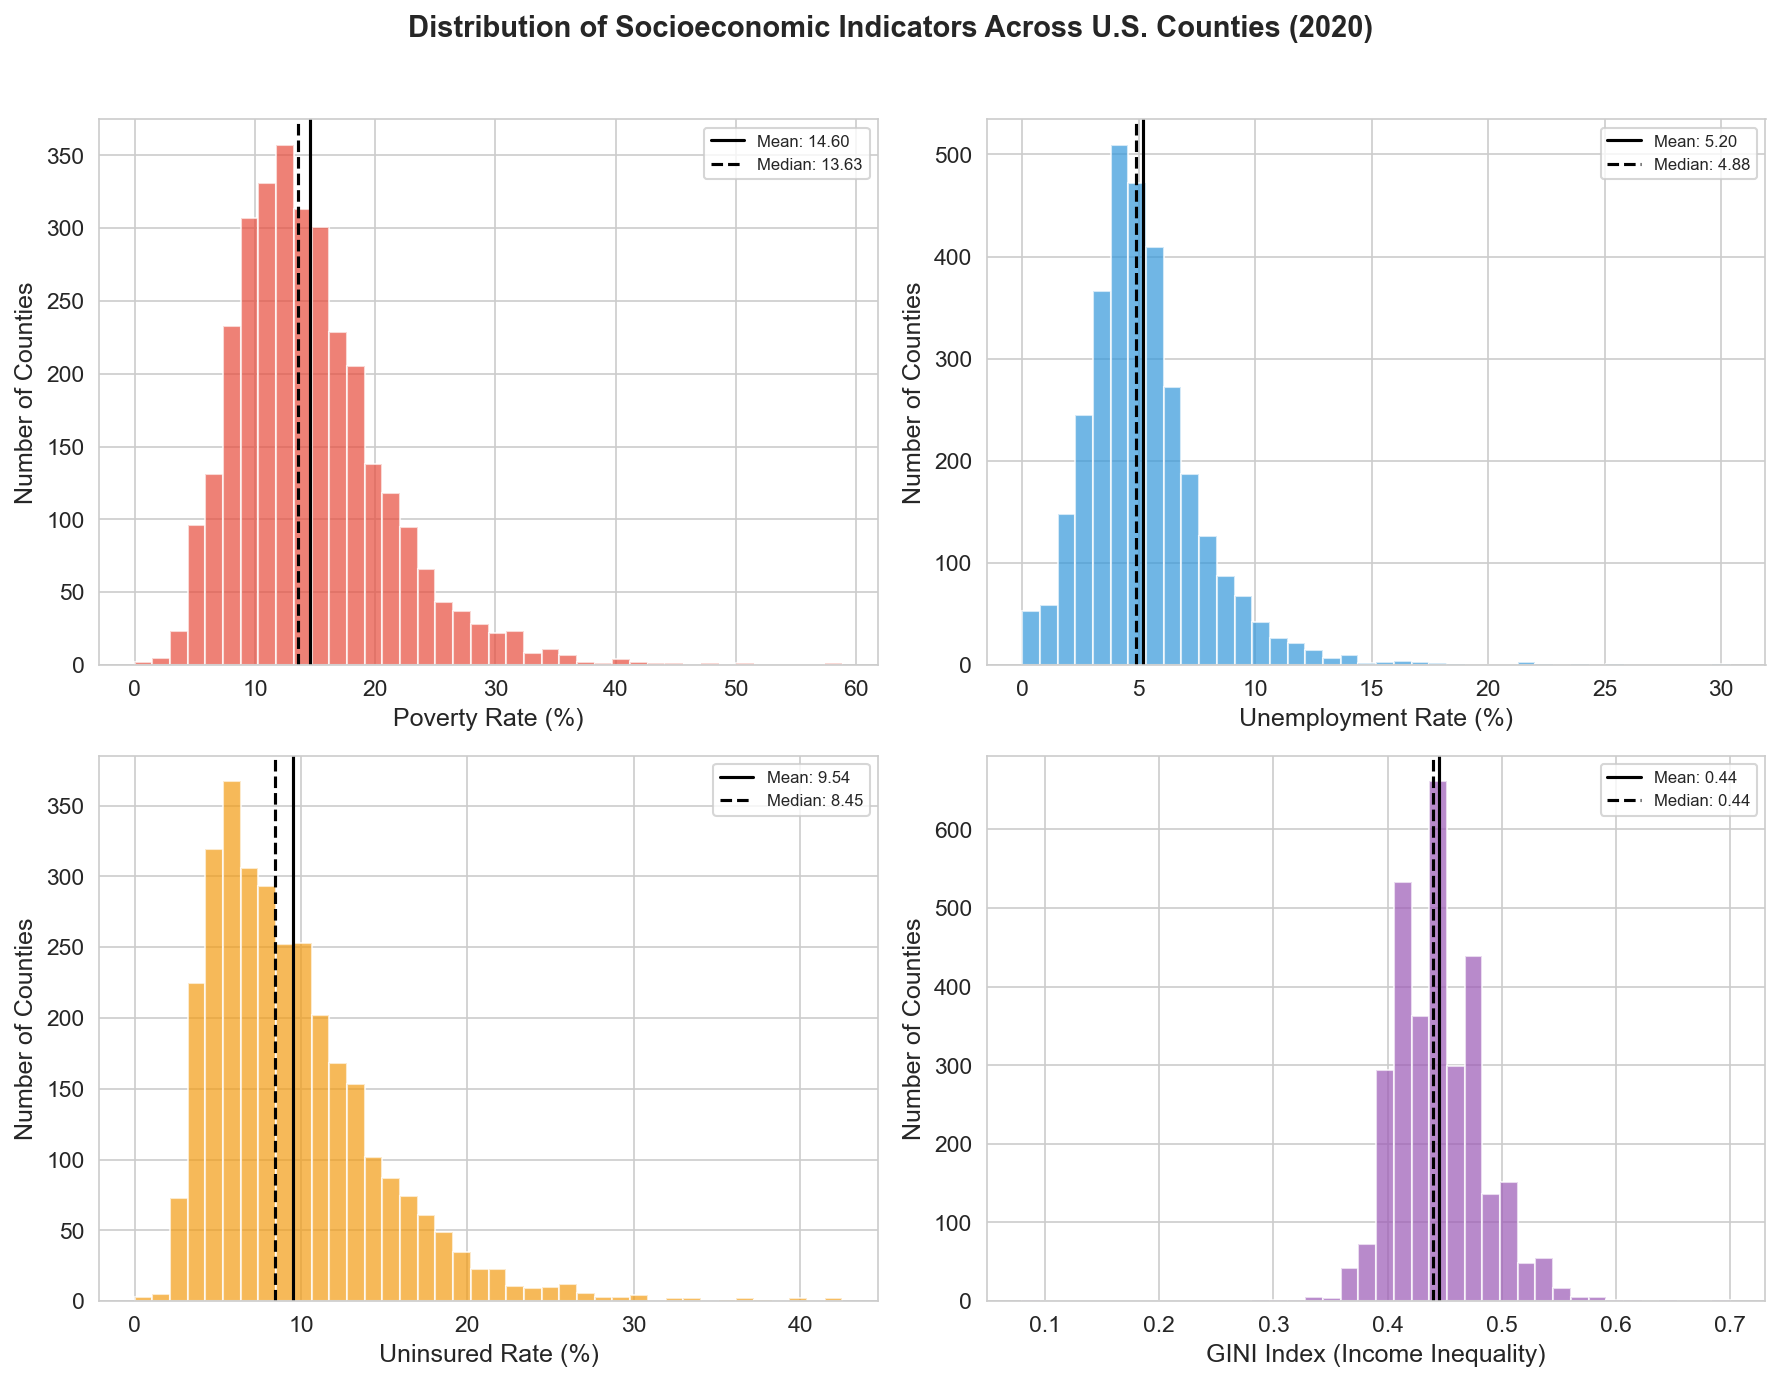

Normality Tests (Shapiro-Wilk on sample of 500):
  Poverty Rate (%)                         p=0.0000 → Normal: No
  Unemployment Rate (%)                    p=0.0000 → Normal: No
  Uninsured Rate (%)                       p=0.0000 → Normal: No
  GINI Index (Income Inequality)           p=0.0000 → Normal: No


In [6]:
# ============================================================
# Viz 5: SDOH Variable Distributions (2x2 grid)
# ============================================================

# Load deduplicated SDOH data (divide by 2 not needed — we use DISTINCT)
sdoh_data = pd.read_sql("""
    SELECT DISTINCT countyfips, pct_poverty, pct_unemployed,
           pct_uninsured, gini_index, total_population
    FROM stg_ahrq_sdoh
    WHERE total_population IS NOT NULL
      AND total_population > 0
      AND statefips NOT IN ('60','66','69','72','78')  -- Exclude territories
""", engine)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

variables = [
    ('pct_poverty', 'Poverty Rate (%)', '#e74c3c'),
    ('pct_unemployed', 'Unemployment Rate (%)', '#3498db'),
    ('pct_uninsured', 'Uninsured Rate (%)', '#f39c12'),
    ('gini_index', 'GINI Index (Income Inequality)', '#9b59b6'),
]

for ax, (col, label, color) in zip(axes.flat, variables):
    data = sdoh_data[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='-', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of Counties')
    ax.legend(fontsize=8)

fig.suptitle('Distribution of Socioeconomic Indicators Across U.S. Counties (2020)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_sdoh_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Normality check (informs Pearson vs Spearman choice in Phase 4)
print('Normality Tests (Shapiro-Wilk on sample of 500):')
for col, label, _ in variables:
    sample = sdoh_data[col].dropna().sample(min(500, len(sdoh_data)), random_state=42)
    stat, p = stats.shapiro(sample)
    normal = 'Yes' if p > 0.05 else 'No'
    print(f'  {label:40s} p={p:.4f} → Normal: {normal}')

### ✏️ Viz 5 Observations
_(Fill in: Are distributions normal or skewed? Which variable has the most variation? The normality results inform whether we use Pearson or Spearman correlation in Phase 4.)_

---
## Visualization 6: Prescribing Rate vs. Death Rate (The Core Hypothesis)

**This is the most important chart in Phase 2.** It's our first look at the central hypothesis:
do states with more opioid prescribing also have more overdose deaths?

**Business relevance**: If the correlation is strong, it validates the stakeholder's approach of
targeting prescribing behavior. If weak, the illicit fentanyl confound may dominate.

In [7]:
# ============================================================
# Viz 6: Scatter — Prescribing Rate vs Death Rate by State
# ============================================================

# Step 1: Get prescribing rate per state (already calculated above, but redo cleanly)
rx_by_state = pd.read_sql(f"""
    SELECT d.state_abbrev, d.state_name, d.census_region,
           SUM(c.tot_clms) AS opioid_claims
    FROM stg_cms_partd c
    JOIN dim_state d ON TRIM(c.prscrbr_state_abrvtn) = d.state_abbrev
    WHERE c.gnrc_name NOT IN ({FALSE_POSITIVES})
    GROUP BY d.state_abbrev, d.state_name, d.census_region;
""", engine)

# Step 2: Get death count per state (using best indicator, deduplicated)
deaths_by_state = pd.read_sql("""
    SELECT DISTINCT state_name, data_value AS opioid_deaths
    FROM stg_cdc_overdose
    WHERE year = 2020
      AND month = 'December'
      AND indicator LIKE 'Natural & semi-synthetic opioids, incl. methad%%'
      AND state_name != 'United States'
      AND state_name != 'New York City'
      AND data_value IS NOT NULL;
""", engine)

# Step 3: Get state population (deduplicated)
state_pop = pd.read_sql("""
    SELECT d.state_abbrev, d.state_name,
           SUM(s.total_population) / 2 AS state_pop  -- Dedup: each county appears twice
    FROM stg_ahrq_sdoh s
    JOIN dim_state d ON s.statefips = d.state_fips
    WHERE s.total_population IS NOT NULL
    GROUP BY d.state_abbrev, d.state_name;
""", engine)

# Step 4: Merge all three
scatter_df = rx_by_state.merge(deaths_by_state, on='state_name', how='inner')
scatter_df = scatter_df.merge(state_pop, on=['state_abbrev', 'state_name'], how='inner')

# Calculate rates
scatter_df['rx_rate'] = scatter_df['opioid_claims'] / scatter_df['state_pop'] * 1000
scatter_df['death_rate'] = scatter_df['opioid_deaths'] / scatter_df['state_pop'] * 100000

print(f'States with both prescribing AND death data: {len(scatter_df)}')
display(scatter_df[['state_abbrev', 'rx_rate', 'death_rate', 'census_region']].head(10))

States with both prescribing AND death data: 41


,state_abbrev,rx_rate,death_rate,census_region
0,AK,187.318688,11.940461,West
1,AZ,332.224524,10.760986,West
2,CO,293.427214,11.609650,West
3,CT,273.147427,17.420295,Northeast
4,DC,156.880454,18.804115,South
5,DE,345.823714,16.947786,South
6,GA,438.315391,9.242550,South
7,HI,165.992758,4.084294,West
8,IA,339.078924,4.190463,Midwest
9,IL,279.849175,10.946697,Midwest


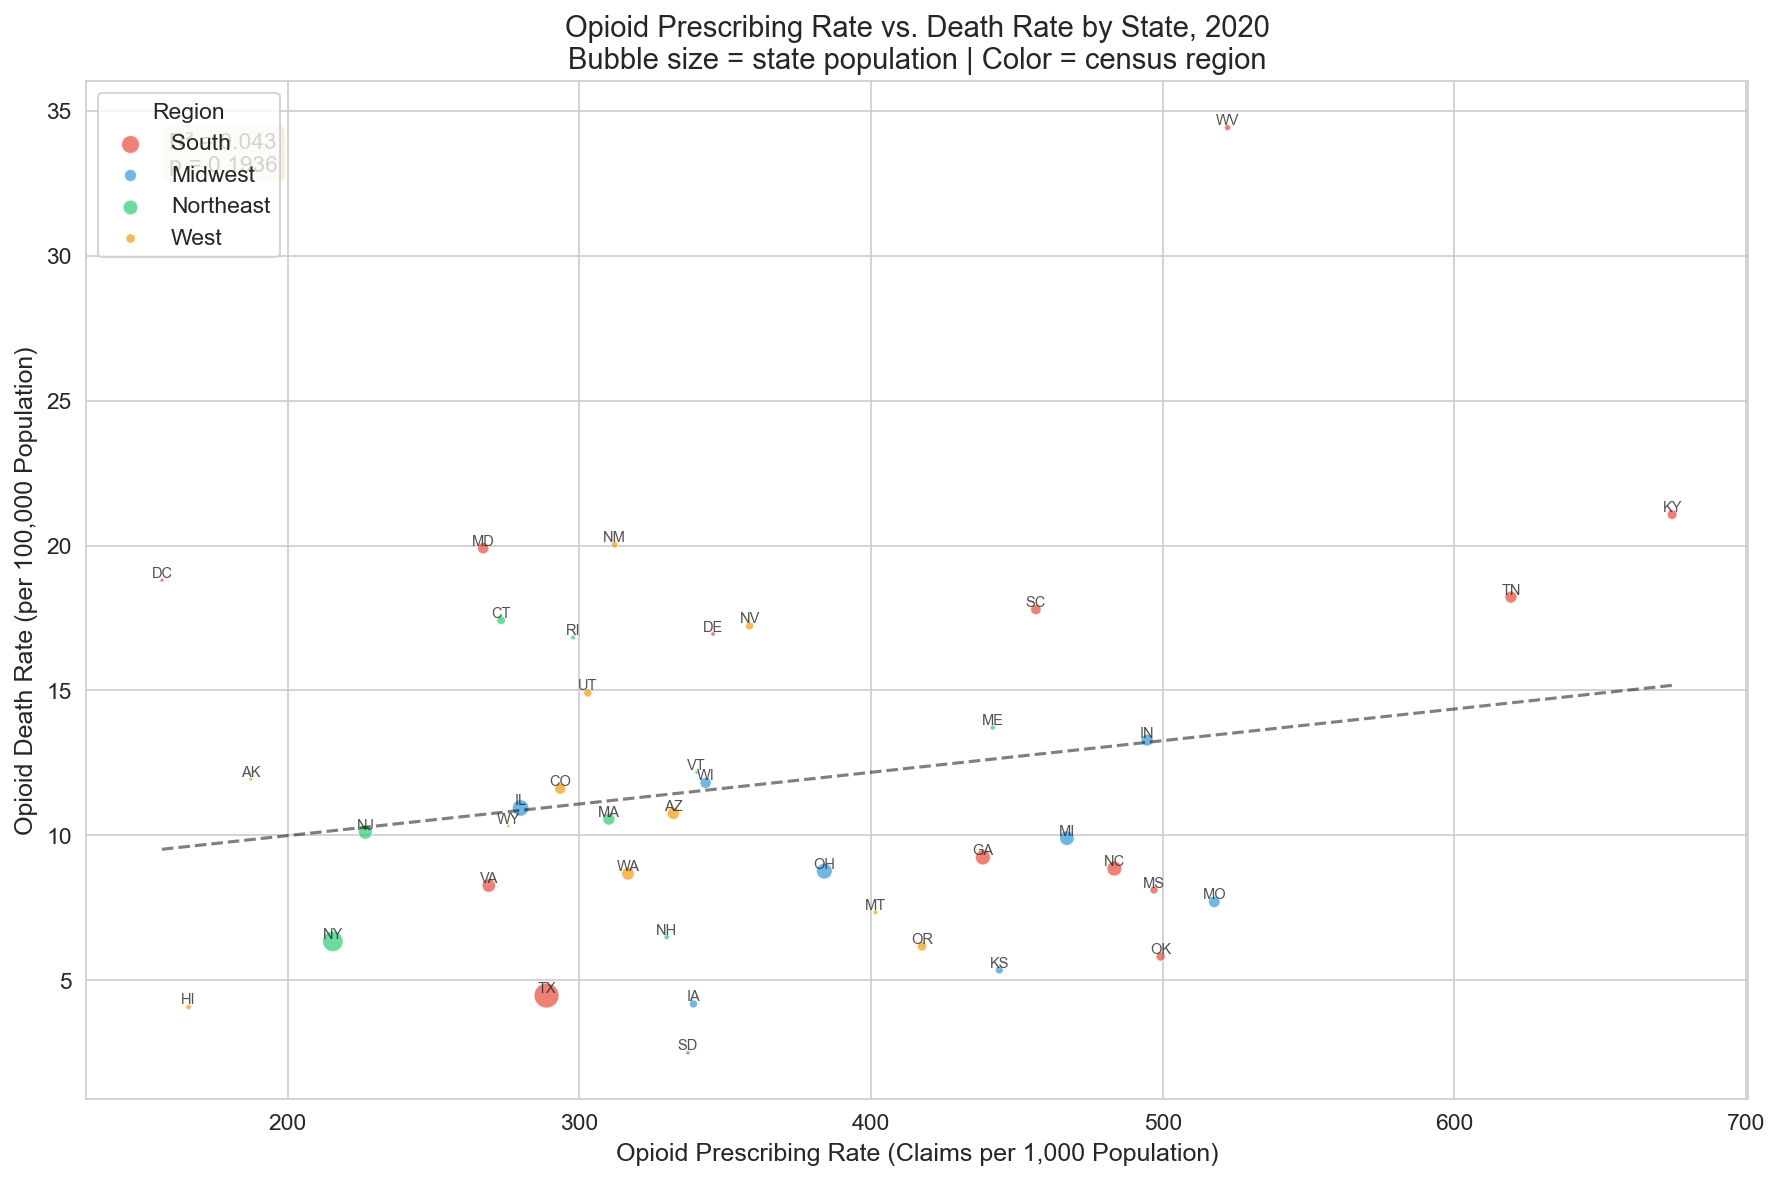


Pearson:  r=0.207, p=0.1936
Spearman: r=0.050, p=0.7570


In [8]:
# ============================================================
# Viz 6: The Scatter Plot
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

region_colors = {'South': '#e74c3c', 'Midwest': '#3498db',
                 'Northeast': '#2ecc71', 'West': '#f39c12'}

for region, color in region_colors.items():
    mask = scatter_df['census_region'] == region
    ax.scatter(
        scatter_df.loc[mask, 'rx_rate'],
        scatter_df.loc[mask, 'death_rate'],
        s=scatter_df.loc[mask, 'state_pop'] / 1e5,  # Bubble size = population
        c=color, alpha=0.7, edgecolors='white', linewidth=0.5,
        label=region
    )

# Add state labels
for _, row in scatter_df.iterrows():
    ax.annotate(row['state_abbrev'], (row['rx_rate'], row['death_rate']),
                fontsize=7, ha='center', va='bottom', alpha=0.8)

# Trend line + R²
slope, intercept, r_value, p_value, std_err = stats.linregress(
    scatter_df['rx_rate'], scatter_df['death_rate']
)
x_line = np.linspace(scatter_df['rx_rate'].min(), scatter_df['rx_rate'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k--', alpha=0.5, linewidth=1.5)

# Annotate R² and p-value
ax.text(0.05, 0.95, f'R² = {r_value**2:.3f}\np = {p_value:.4f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Opioid Prescribing Rate (Claims per 1,000 Population)')
ax.set_ylabel('Opioid Death Rate (per 100,000 Population)')
ax.set_title('Opioid Prescribing Rate vs. Death Rate by State, 2020\n'
             'Bubble size = state population | Color = census region')
ax.legend(title='Region', loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_prescribing_vs_deaths_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlation stats
r_pearson, p_pearson = stats.pearsonr(scatter_df['rx_rate'], scatter_df['death_rate'])
r_spearman, p_spearman = stats.spearmanr(scatter_df['rx_rate'], scatter_df['death_rate'])
print(f'\nPearson:  r={r_pearson:.3f}, p={p_pearson:.4f}')
print(f'Spearman: r={r_spearman:.3f}, p={p_spearman:.4f}')

### ✏️ Viz 6 Observations (MOST IMPORTANT)
_(Fill in: Is the correlation positive? Is it statistically significant (p < 0.05)? How strong is R²? Which states are outliers — high death rate despite low prescribing (fentanyl states?) or high prescribing despite low death rate? Does the South cluster in the high-prescribing region?)_

---
## Visualization 7: Data Completeness Heatmap

**Business relevance**: Shows the stakeholder which states have reliable data and which don't —
ensuring transparency about the evidence base behind any recommendations.

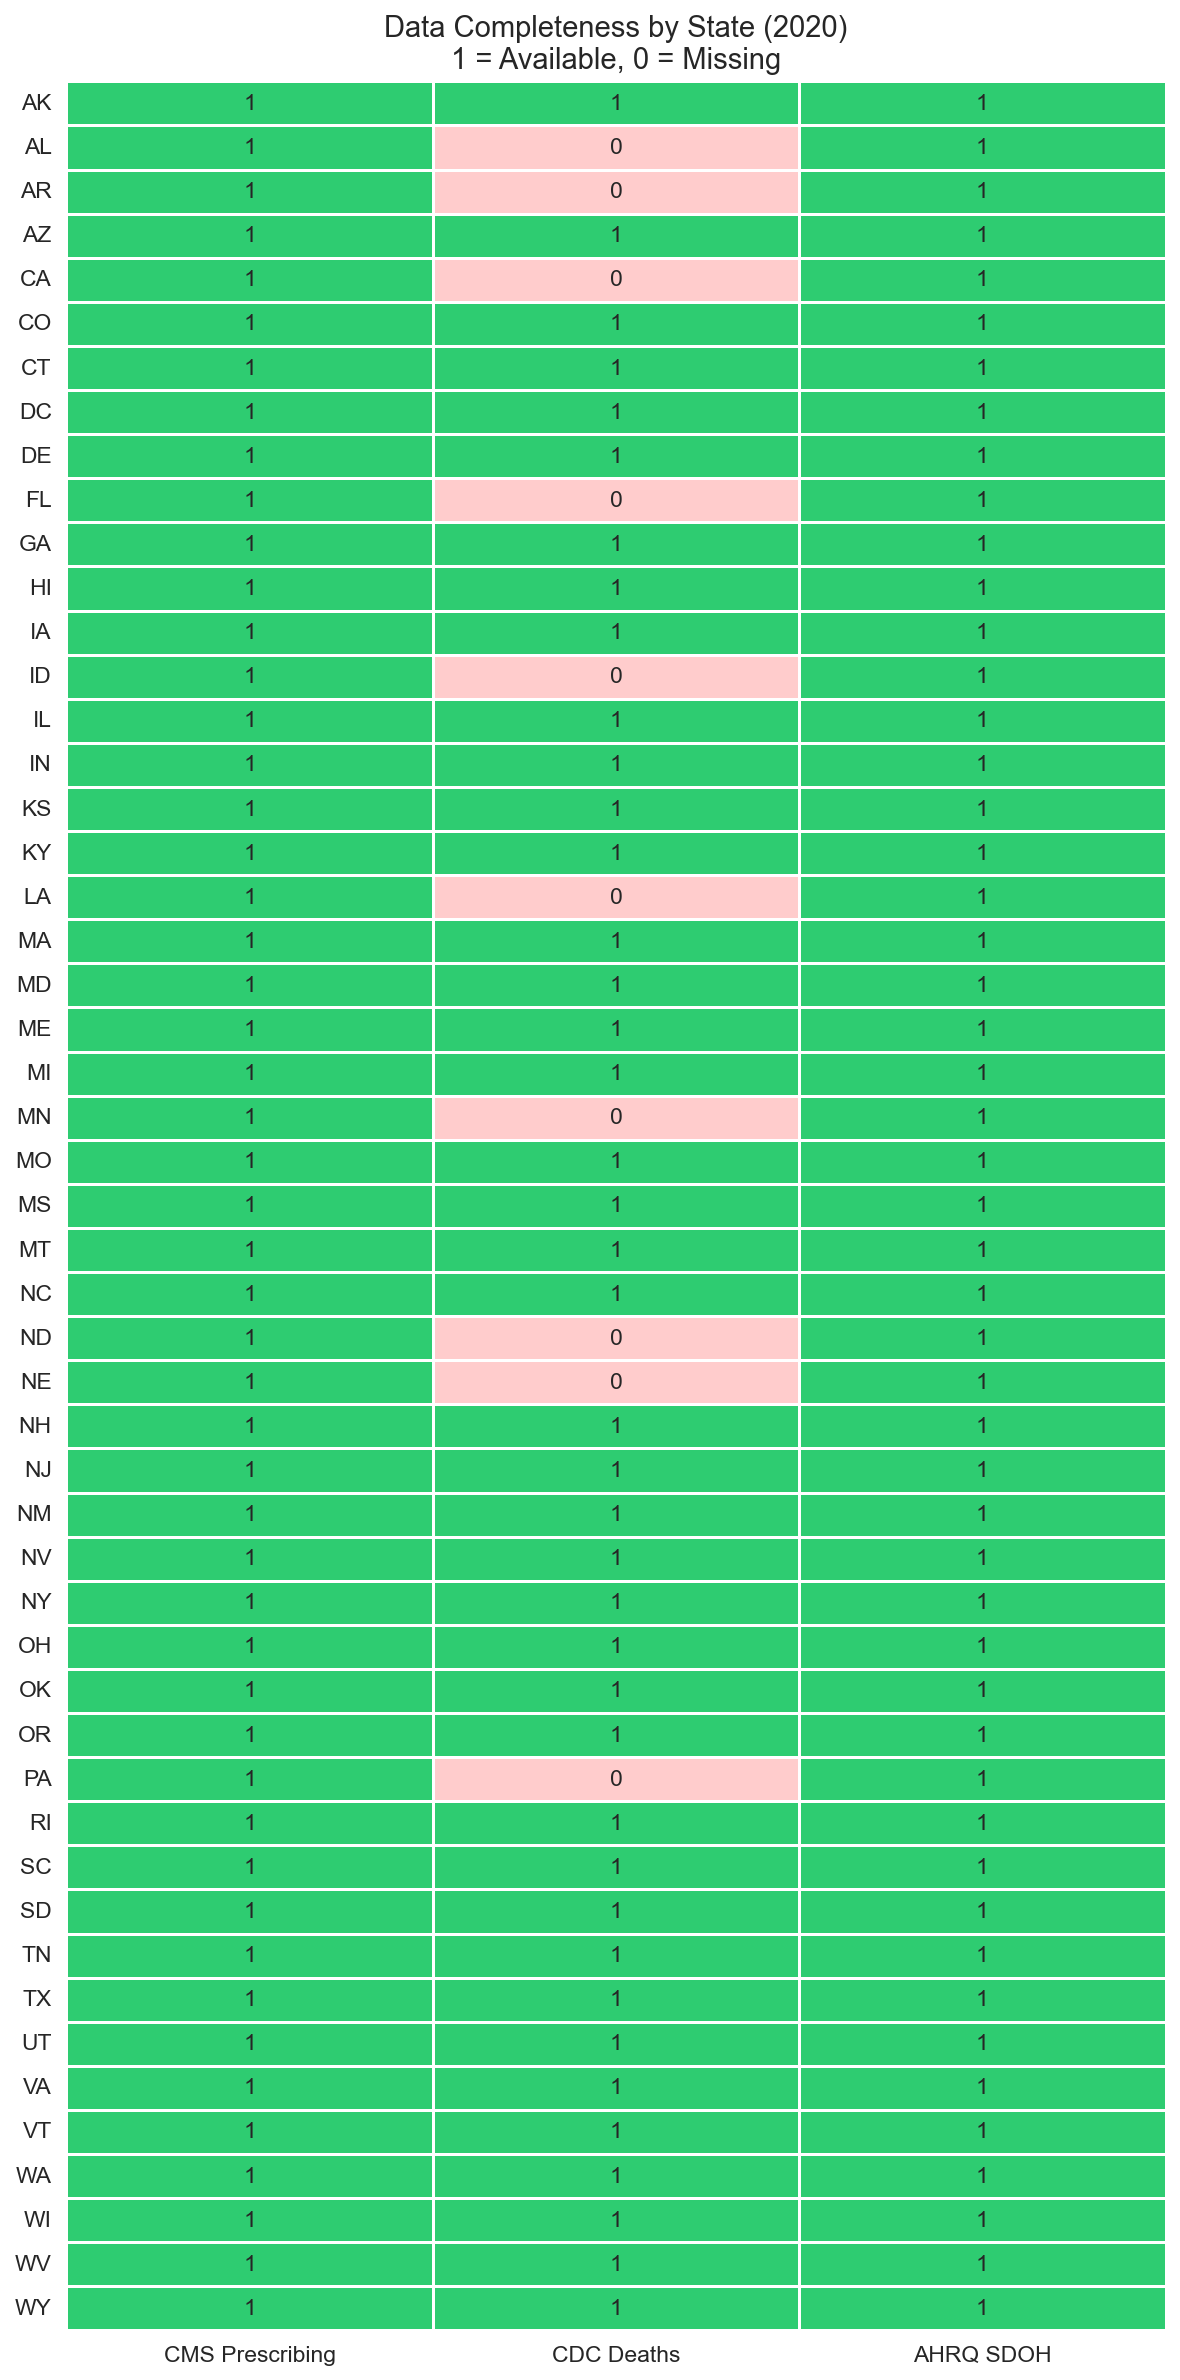


States with ALL THREE datasets: 41 of 51
States missing CDC death data: ['AL', 'AR', 'CA', 'FL', 'ID', 'LA', 'MN', 'ND', 'NE', 'PA']


In [9]:
# ============================================================
# Viz 7: Data Completeness Heatmap by State
# ============================================================

# Check which states have data in each dataset
# CMS: all 51 states have data
cms_states = pd.read_sql(f"""
    SELECT DISTINCT d.state_abbrev
    FROM stg_cms_partd c
    JOIN dim_state d ON TRIM(c.prscrbr_state_abrvtn) = d.state_abbrev
    WHERE c.gnrc_name NOT IN ({FALSE_POSITIVES})
""", engine)['state_abbrev'].str.strip().tolist()

# CDC: check which states have our target indicator
cdc_states = pd.read_sql("""
    SELECT DISTINCT d.state_abbrev
    FROM stg_cdc_overdose c
    JOIN dim_state d ON c.state_name = d.state_name
    WHERE c.year = 2020 AND c.month = 'December'
      AND c.indicator LIKE 'Natural & semi-synthetic opioids, incl. methad%%'
      AND c.data_value IS NOT NULL
""", engine)['state_abbrev'].str.strip().tolist()

# AHRQ: check which states have SDOH data
sdoh_states = pd.read_sql("""
    SELECT DISTINCT d.state_abbrev
    FROM stg_ahrq_sdoh s
    JOIN dim_state d ON s.statefips = d.state_fips
    WHERE s.total_population IS NOT NULL
""", engine)['state_abbrev'].str.strip().tolist()

# Build completeness matrix
all_states = pd.read_sql('SELECT state_abbrev FROM dim_state ORDER BY state_abbrev', engine)
completeness = all_states.copy()
completeness['state_abbrev'] = completeness['state_abbrev'].str.strip()
completeness['CMS Prescribing'] = completeness['state_abbrev'].isin(cms_states).astype(int)
completeness['CDC Deaths'] = completeness['state_abbrev'].isin(cdc_states).astype(int)
completeness['AHRQ SDOH'] = completeness['state_abbrev'].isin(sdoh_states).astype(int)
completeness['All Three'] = (completeness[['CMS Prescribing', 'CDC Deaths', 'AHRQ SDOH']].sum(axis=1) == 3).astype(int)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 16))
heatmap_data = completeness.set_index('state_abbrev')[['CMS Prescribing', 'CDC Deaths', 'AHRQ SDOH']]

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap=['#ffcccc', '#2ecc71'],
            cbar=False, linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Data Completeness by State (2020)\n1 = Available, 0 = Missing')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_data_completeness_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
complete_count = completeness['All Three'].sum()
missing_cdc = completeness[completeness['CDC Deaths'] == 0]['state_abbrev'].tolist()
print(f'\nStates with ALL THREE datasets: {complete_count} of 51')
print(f'States missing CDC death data: {missing_cdc}')

### ✏️ Viz 7 Observations
_(Fill in: How many states have complete data across all 3 datasets? Which states are missing CDC death data? Are any critical high-opioid states missing?)_

---
## Final Data Quality Summary

Consolidating all findings from Part 1 (profiling) and Part 2 (EDA).

### Data Quality Issues & Resolutions

| # | Issue | Dataset | Severity | Resolution |
|---|-------|---------|----------|------------|
| 1 | No `Opioid_Drug_Flag` column | CMS | High | Built 17-pattern drug name filter |
| 2 | 5 false-positive non-opioid drugs | CMS | Medium | Exclude Tiotropium, Ipratropium (×2), Tiotropium/Olodaterol, Apomorphine |
| 3 | `Tot_Benes` 54% suppressed | CMS | Medium | Use `Tot_Clms` as primary metric; note limitation |
| 4 | Near-duplicate specialties | CMS | Low | Merge 'Family Practice' + 'Family Medicine' in Phase 3 |
| 5 | 9 territory/military codes | CMS | Low | Exclude (no matching CDC/SDOH data) |
| 6 | Broad opioid indicator covers only 20 states | CDC | **Critical** | Switch to 'Natural & semi-synthetic opioids, incl. methadone (T40.2, T40.3)' (42 states) |
| 7 | All rows duplicated | CDC & AHRQ | Medium | Deduplicate with DISTINCT |
| 8 | Join key mismatch | CDC | Medium | Use `state_name` column, not `state` |
| 9 | 'New York City' separate from 'New York' | CDC | Low | Exclude NYC (deaths likely included in NY state total) |
| 10 | 5 territory FIPS codes | AHRQ | Low | Exclude FIPS 60, 66, 69, 72, 78 |
| 11 | 26 counties with NULL population | AHRQ | Low | Exclude from weighted aggregation |
| 12 | MN counties 27111/27165 present | AHRQ | Low | Data looks correct; verify in Phase 3 |
| 13 | CMS file encoding (latin-1) | CMS | Low | Fixed with `encoding='latin-1'` |
| 14 | AHRQ Excel default sheet = codebook | AHRQ | Low | Fixed with `sheet_name='Data'` |

---
## 10 Documented Decisions for Phase 3

These decisions are the output of Phase 2 and will guide all Phase 3 work.

### Decision 1: Analysis Year
**Choice**: 2020 (single year)  
**Rationale**: Most recent year with full overlap across all three datasets. AHRQ SDOH ends at 2020 (binding constraint). Captures COVID-19's first-year impact on overdose deaths.

### Decision 2: CMS Data Scope
**Choice**: Opioid-only rows, filtered by 17-pattern drug name list  
**Rationale**: File lacks `Opioid_Drug_Flag`. Drug name filtering captured all expected opioids. 5 false positives identified and will be excluded. Total: ~3.4M rows → ~3.2M after false positive removal.

### Decision 3: CDC Opioid Indicator
**Choice**: `Natural & semi-synthetic opioids, incl. methadone (T40.2, T40.3)` as primary  
**Rationale**: Broadest indicator `Opioids (T40.0-T40.4,T40.6)` only covers 20/51 states. The chosen indicator covers 42 states and better matches our CMS prescribing data (prescribed opioids, not illicit fentanyl).  
**Limitation**: Excludes synthetic opioid (illicit fentanyl) deaths. Death counts understate total opioid mortality.

### Decision 4: CDC Completeness Threshold
**Choice**: ≥85% `Percent Complete`  
**Rationale**: All states show 100% completeness for December 2020. No exclusions needed on this criterion.

### Decision 5: AHRQ SDOH Year and Variables
**Choice**: 2020 county-level data with 6 variables  
**Variables**: `ACS_PCT_PERSON_INC_BELOW99` (poverty), `ACS_PCT_UNEMPLOY`, `ACS_MEDIAN_HH_INC`, `ACS_GINI_INDEX`, `ACS_PCT_UNINSURED`, `ACS_TOT_POP_WT` (population)  
**Rationale**: All 6 variables have <1% missing. Population available for weighting.

### Decision 6: Territory Exclusion
**Choice**: Exclude all territories (PR, GU, VI, AS, MP) and military codes (AA, AE, AP, XX, ZZ)  
**Rationale**: Territories lack matching data across all three datasets. Analysis covers 50 states + DC = 51 jurisdictions.

### Decision 7: Suppressed Value Handling
**Choice**: CMS — use `Tot_Clms` (0% null) as primary metric, not `Tot_Benes` (54% null). CDC — states with NULL death counts excluded from analysis (9 states for primary indicator).  
**Rationale**: `Tot_Clms` captures prescribing volume without suppression bias.

### Decision 8: Deduplication Strategy
**Choice**: Apply `DISTINCT` or `DROP DUPLICATES` to both CDC and AHRQ data  
**Rationale**: Both files contain exact duplicate rows (every row appears twice). CDC: 163,800 → ~81,900. AHRQ: 6,468 → ~3,234.

### Decision 9: County-to-State Aggregation
**Choice**: Population-weighted averages for SDOH variables  
**Rationale**: Simple means would treat a county of 500 people equally with a county of 5 million. Population weighting produces state-level averages that reflect where people actually live.  
**Formula**: `state_avg = SUM(county_value × county_pop) / SUM(county_pop)`

### Decision 10: Initial Scatter Plot Assessment
**Choice**: _(Fill in after running Viz 6)_  
**Observation**: _(Fill in: What R² did you see? Was the correlation significant? This determines whether the project's core hypothesis holds.)_  
**Implication**: _(Fill in: If R² > 0.2, the prescribing-death link is worth modeling. If near zero, the illicit fentanyl confound may dominate and we should adjust our framing.)_

---
## Phase 2 Complete — Transition to Phase 3

### Checklist
- [x] All three datasets loaded and profiled
- [x] 7 EDA visualizations created and saved to `figures/`
- [x] Data quality issues identified and documented (14 issues)
- [x] 10 decisions documented for Phase 3
- [x] Cross-dataset join validation confirmed (51 states joinable)
- [x] Initial correlation assessed (Viz 6)

### What Happens in Phase 3 (Data Preparation)
1. Clean CMS: remove false positives, consolidate specialties, exclude territories
2. Clean CDC: deduplicate, filter to target indicator + December 2020, exclude aggregates
3. Clean AHRQ: deduplicate, exclude territories, aggregate county → state (population-weighted)
4. Master merge: 4-CTE SQL query joining all three through `dim_state`
5. Engineer 14 features in the `fact_opioid_analysis` table